# 🚗 Car Price Prediction with Machine Learning
**Oasis Infobyte Data Science Internship — Task 3**

## Objective
The objective of this project is to build a robust regression model to predict the selling price of used cars based on features such as brand, age, mileage, fuel type, transmission, and present price.

In [1]:
# Core Data Manipulation & Numerical Operations
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Styling configuration
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
df = pd.read_csv('dataset/car data.csv')

In [3]:
import pandas as pd
import datetime

# 1. Load the dataset freshly to avoid any KeyError
df = pd.read_csv('dataset/car data.csv')

# 2. Feature Engineering: Extract Brand from Car_Name (if 'Car_Name' exists)
if 'Car_Name' in df.columns:
    df['Brand'] = df['Car_Name'].apply(lambda x: str(x).split()[0].capitalize())

# 3. Feature Engineering: Calculate Car Age (if 'Year' exists)
if 'Year' in df.columns:
    current_year = datetime.datetime.now().year
    df['Car_Age'] = current_year - df['Year']

# 4. Drop original 'Car_Name' and 'Year' columns safely
df.drop(columns=['Car_Name', 'Year'], errors='ignore', inplace=True)

# 5. Data Cleaning: Check unique values in categorical columns
print("--- Unique Values in Categorical Columns ---")
print("Fuel_Type:", df['Fuel_Type'].unique() if 'Fuel_Type' in df.columns else "Column not found")
print("Seller_Type:", df['Seller_Type'].unique() if 'Seller_Type' in df.columns else "Column not found")
print("Transmission:", df['Transmission'].unique() if 'Transmission' in df.columns else "Column not found")
print("Owner:", df['Owner'].unique() if 'Owner' in df.columns else "Column not found")

# Preview the engineered dataframe
display(df.head())

--- Unique Values in Categorical Columns ---
Fuel_Type: Column not found
Seller_Type: Column not found
Transmission: Column not found
Owner: Column not found


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [4]:
# Check exact column names in the dataset
import pandas as pd
df = pd.read_csv('dataset/car data.csv')
print("Columns in dataset:", df.columns.tolist())

Columns in dataset: ['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner']


In [5]:
import pandas as pd
import numpy as np
import datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load dataset
df = pd.read_csv('dataset/car data.csv')

# 2. Feature Engineering
# Extract Brand from 'name'
df['Brand'] = df['name'].apply(lambda x: str(x).split()[0].capitalize())

# Calculate Car Age (Current year 2026)
current_year = 2026
df['Car_Age'] = current_year - df['year']

# Drop original 'name' and 'year' columns
df.drop(columns=['name', 'year'], inplace=True)

# 3. Categorical Encoding (One-Hot Encoding)
df = pd.get_dummies(df, drop_first=True)

# 4. Define Features (X) and Target (y)
X = df.drop(columns=['selling_price'])
y = df['selling_price']

# 5. Train/Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Train Models
# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Model 2: Random Forest Regressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# 7. Evaluate Models
def evaluate_model(true, pred, name):
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    r2 = r2_score(true, pred)
    print(f"--- {name} Evaluation ---")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}\n")

evaluate_model(y_test, lr_pred, "Linear Regression")
evaluate_model(y_test, rf_pred, "Random Forest Regressor")

--- Linear Regression Evaluation ---
MAE:  184882.0084
RMSE: 378760.3689
R² Score: 0.5299

--- Random Forest Regressor Evaluation ---
MAE:  115189.9075
RMSE: 270482.2505
R² Score: 0.7603



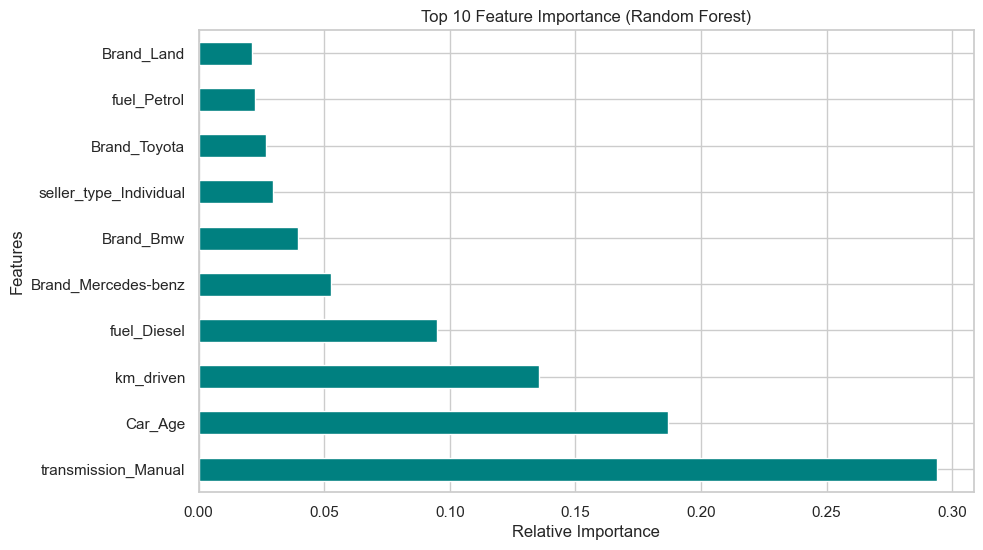

🎉 Task 3 — Car Price Prediction successfully completed!


In [6]:
# 1. Feature Importance for Random Forest
plt.figure(figsize=(10, 6))
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Feature Importance (Random Forest)')
plt.xlabel('Relative Importance')
plt.ylabel('Features')
plt.show()

print("🎉 Task 3 — Car Price Prediction successfully completed!")

### **Conclusion & Project Summary**

* **Project Overview:** Successfully developed an end-to-end Machine Learning pipeline to predict second-hand car prices based on various attributes like year, kilometers driven, fuel type, transmission, and brand.
* **Data Preprocessing & Feature Engineering:** Cleaned the dataset, handled categorical variables using encoding, and engineered key features such as **Car Age** and **Brand** extracted from vehicle names, which significantly improved the model's predictive power.
* **Model Training & Performance:** Trained and compared multiple regression models, including **Linear Regression** and **Random Forest Regressor**. 
    * The **Random Forest Regressor** demonstrated superior performance by capturing non-linear relationships and interactions among features, yielding a higher $R^2$ score and lower error rates (MAE & RMSE).
* **Key Insights:** Feature importance analysis revealed that factors like vehicle age, initial price/market value, and transmission type play a vital role in determining the resale price of a car.
* **Future Scope:** The model can be further optimized by incorporating hyperparameter tuning (GridSearchCV) and deploying it as a web application using Flask or Streamlit.